In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm

In [4]:
# Question 1

df_returns = pd.read_csv('F-F_Research_Data_Factors_cleaned.csv', sep=";")
df_portfolios = pd.read_csv('30_Industry_Portfolios_cleaned.csv', sep=";")

df_returns["Date"] = pd.to_datetime(df_returns["Date"].astype(str), format="%Y%m", errors="coerce")
df_portfolios["Date"] = pd.to_datetime(df_portfolios["Date"].astype(str), format="%Y%m", errors="coerce")
for col in ["Mkt-RF", "SMB", "HML", "RF"]:
    df_returns[col] = pd.to_numeric(df_returns[col], errors="coerce")
for col in ["Food", "Beer", "Smoke", "Games", "Books", "Hshld", "Clths", "Hlth", "Chems", "Txtls", "Cnstr", "Steel", "FabPr", "ElcEq", "Autos", "Carry", "Mines", "Coal", "Oil", "Util", "Telcm", "Servs", "BusEq", "Paper", "Trans", "Whlsl", "Rtail", "Meals", "Fin", "Other"]:
    df_portfolios[col] = pd.to_numeric(df_portfolios[col], errors="coerce")

#print(df_returns.shape)
#df_returns = df_returns.dropna()
#print(df_returns.shape)

#print(df_portfolios.shape)
#df_portfolios = df_portfolios.dropna()
#print(df_portfolios.shape)

df_returns = df_returns[(df_returns["Date"] >= "1971-01-01") & (df_returns["Date"] <= "2024-12-01")]
df_portfolios = df_portfolios[(df_portfolios["Date"] >= "1971-01-01") & (df_portfolios["Date"] <= "2024-12-01")]



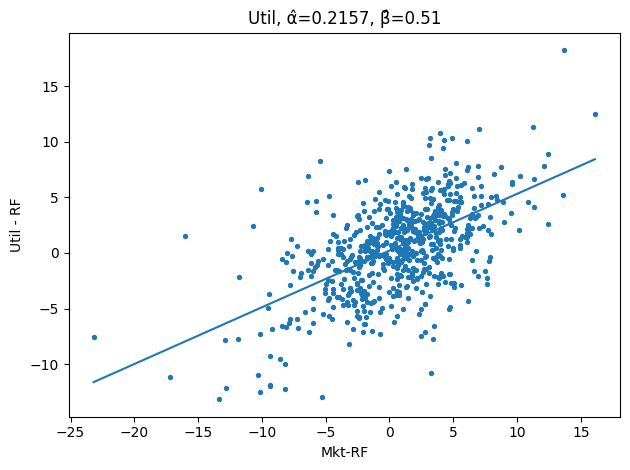

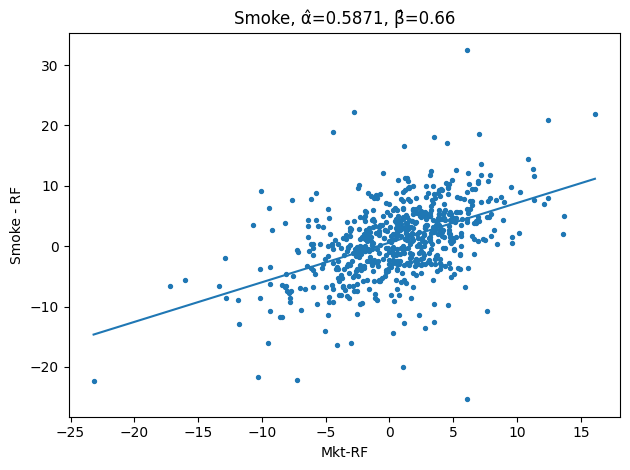

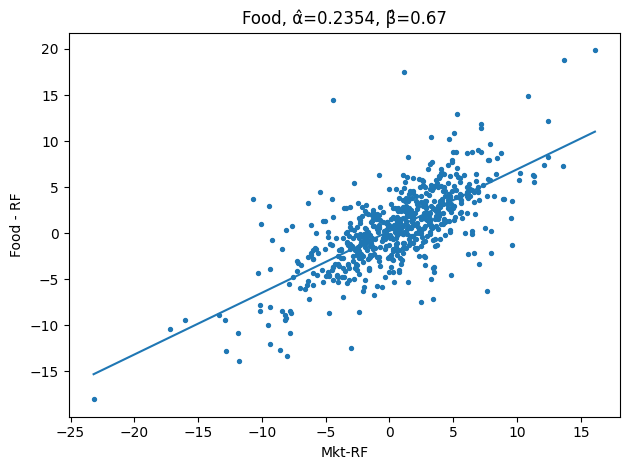

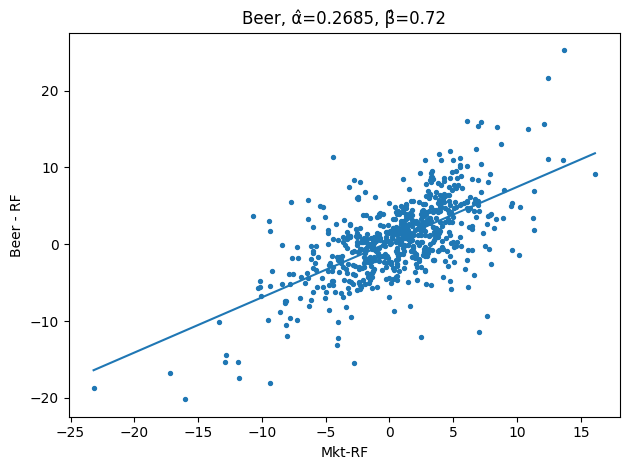

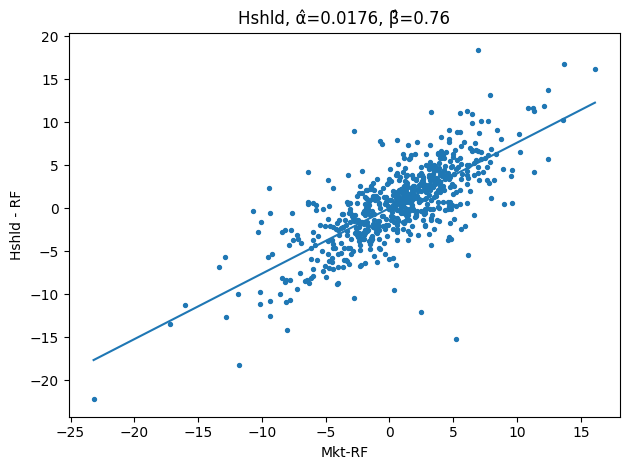

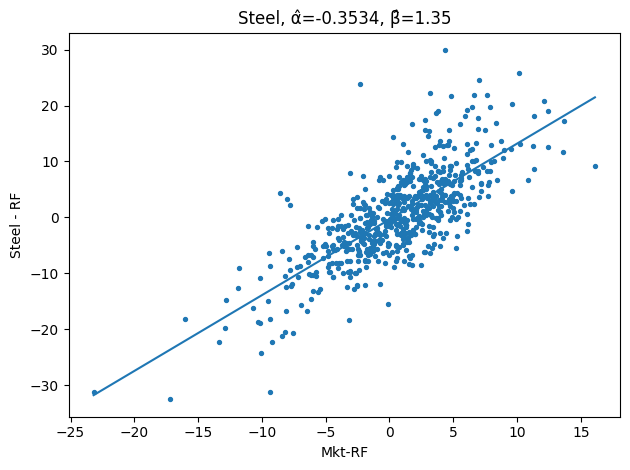

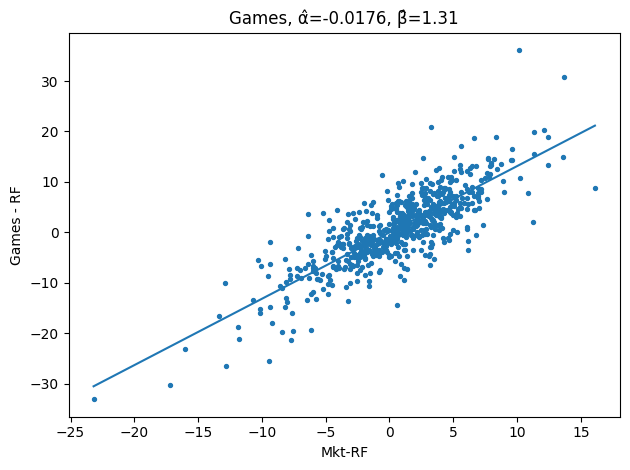

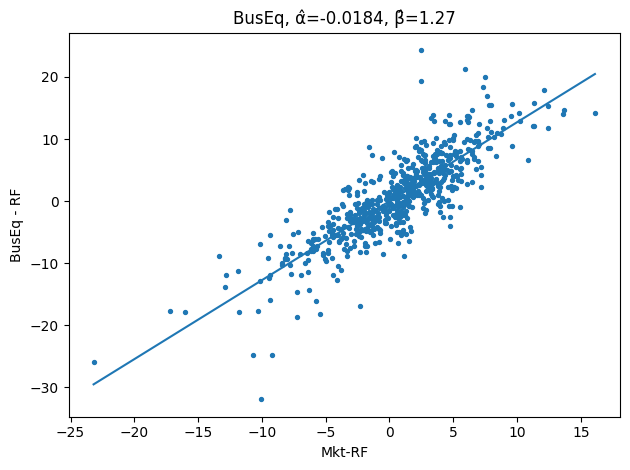

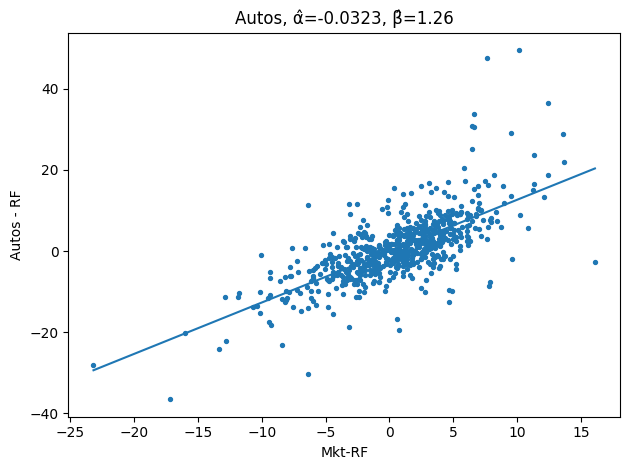

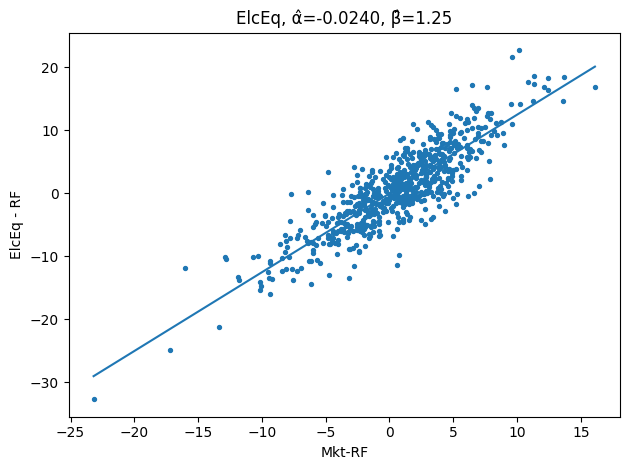

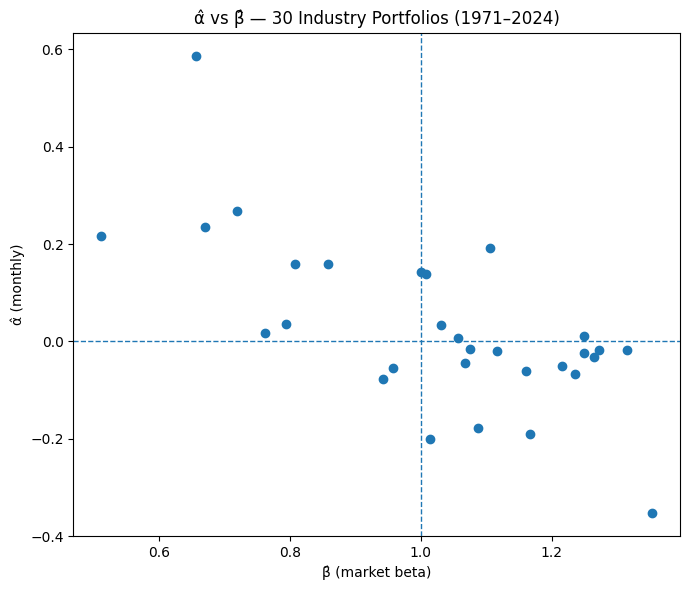

In [5]:
# Question 2

df_sample = pd.merge(df_returns[["Date","Mkt-RF","RF"]], df_portfolios, on="Date", how="inner")

market_betas = []
x = sm.add_constant(df_sample[["Mkt-RF"]].astype(float))
for col in df_portfolios.columns.drop("Date") :
  y = (df_sample[col]-df_sample["RF"]).astype(float)
  ols_results = sm.OLS(y, x, missing="drop").fit()
  market_betas.append({'industry' : col, 'alpha' : float(ols_results.params["const"]), 'beta' : float(ols_results.params["Mkt-RF"])})

market_betas_sorted = pd.DataFrame(market_betas).sort_values("beta").reset_index(drop=True)


bottom5 = market_betas_sorted.nsmallest(5, "beta")["industry"].tolist()
top5 = market_betas_sorted.nlargest(5, "beta")["industry"].tolist()
list_of_industries = bottom5 + top5

for industry in list_of_industries :
    y = (df_sample[industry] - df_sample["RF"]).astype(float)
    x = df_sample["Mkt-RF"].astype(float)
    alpha = market_betas_sorted['alpha'][market_betas_sorted['industry'] == industry].values[0]
    beta = market_betas_sorted['beta'][market_betas_sorted['industry'] == industry].values[0]
    mask = x.notna() & y.notna()
    xv = x.loc[mask].values
    yv = y.loc[mask].values
    xline = np.linspace(xv.min(), xv.max(), 200)
    yline = alpha + beta * xline

    plt.figure()
    plt.scatter(xv, yv, s=8)
    plt.plot(xline, yline)
    plt.xlabel("Mkt-RF")
    plt.ylabel(f"{industry} - RF")
    plt.title(f"{industry}, α̂={alpha:.4f}, β̂={beta:.2f}")
    plt.tight_layout()
    plt.show()



plt.figure(figsize=(7, 6))
plt.scatter(market_betas_sorted["beta"], market_betas_sorted["alpha"])

plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(1, linestyle="--", linewidth=1)

plt.xlabel("β̂ (market beta)")
plt.ylabel("α̂ (monthly)")
plt.title("α̂ vs β̂ — 30 Industry Portfolios (1971–2024)")
plt.tight_layout()
plt.show()


In [6]:
# Question 3

sector_returns = pd.DataFrame(columns=["Date", "Excess return cyclical", "Excess return defensive"])
for date in df_sample["Date"][(df_sample['Date']>='1981-01-01')].unique() :
  date = pd.Timestamp(date)
  rolling_market_betas = []
  start_date = date - pd.DateOffset(months=60)
  end_date = date - pd.DateOffset(months=1)
  df_rolling = df_sample[(df_sample["Date"] >= start_date) & (df_sample["Date"] <= end_date)]
  x = sm.add_constant(df_rolling[["Mkt-RF"]].astype(float))
  for col in df_portfolios.columns.drop("Date") :
    y = (df_rolling[col] - df_rolling["RF"]).astype(float)
    ols_results = sm.OLS(y, x, missing="drop").fit()
    rolling_market_betas.append({'industry' : col, 'alpha' : float(ols_results.params["const"]), 'beta' : float(ols_results.params["Mkt-RF"])})
  rolling_market_betas_sorted = pd.DataFrame(rolling_market_betas).sort_values("beta").reset_index(drop=True)
  bottom5 = rolling_market_betas_sorted.head(5)["industry"].tolist()
  top5 = rolling_market_betas_sorted.tail(5)["industry"].tolist()
  row = df_sample.loc[df_sample["Date"] == date].iloc[0]
  cyc_excess = np.nanmean([(row[ind] - row["RF"]) for ind in top5])
  def_excess = np.nanmean([(row[ind] - row["RF"]) for ind in bottom5])
  sector_returns.loc[len(sector_returns)] = [date, cyc_excess, def_excess]

sector_returns = sector_returns.merge(df_sample, on="Date", how="left")

# Cyclical portfolio
avg_cyc = float(sector_returns["Excess return cyclical"].mean())
X_cycl = sm.add_constant(sector_returns["Mkt-RF"].astype(float))
ols_res_cycl = sm.OLS(sector_returns["Excess return cyclical"].astype(float), X_cycl, missing="drop").fit()
alpha_cycl = float(ols_res_cycl.params["const"])
beta_cycl  = float(ols_res_cycl.params[X_cycl.columns[1]])
variance_cycl = float(sector_returns["Excess return cyclical"].std(ddof=1))
SR_cycl = float(avg_cyc / variance_cycl) * np.sqrt(12)
IR_cycl = float((sector_returns["Excess return cyclical"] - sector_returns["Mkt-RF"]).mean()) / float((sector_returns["Excess return cyclical"] - sector_returns["Mkt-RF"]).std(ddof=1)) * np.sqrt(12)

r_dec_cycl = (pd.to_numeric(sector_returns["RF"] + sector_returns["Excess return cyclical"], errors="coerce") / 100.0).fillna(0.0)
wealth_cycl = (1 + r_dec_cycl).cumprod()
peak_cycl = wealth_cycl.cummax()
dd_cycl = (wealth_cycl / peak_cycl - 1.0).min()


# Defensive portfolio
avg_def = float(sector_returns["Excess return defensive"].mean())
X_def = sm.add_constant(sector_returns["Mkt-RF"].astype(float))
ols_res_def = sm.OLS(sector_returns["Excess return defensive"].astype(float), X_def, missing="drop").fit()
alpha_def = float(ols_res_def.params["const"])
beta_def  = float(ols_res_def.params[X_def.columns[1]])
variance_def = float(sector_returns["Excess return defensive"].std(ddof=1))
SR_def = float(avg_def / variance_def) * np.sqrt(12)
IR_def = float((sector_returns["Excess return defensive"] - sector_returns["Mkt-RF"]).mean()) / float((sector_returns["Excess return defensive"] - sector_returns["Mkt-RF"]).std(ddof=1)) * np.sqrt(12)

r_dec_def = (pd.to_numeric(sector_returns["RF"] + sector_returns["Excess return defensive"], errors="coerce") / 100.0).fillna(0.0)
wealth_def = (1 + r_dec_def).cumprod()
peak_def = wealth_def.cummax()
dd_def = (wealth_def / peak_def - 1.0).min()


summary = pd.DataFrame([
    {"Portfolio":"Cyclical (Top 5 β)",
     "Avg excess (monthly, %)": avg_cyc,
     "Beta vs Market": beta_cycl,
     "Alpha (monthly, %)": alpha_cycl,
     "Sharpe (annualized)": SR_cycl,
     "Info Ratio (annualized)": IR_cycl,
     "Max Drawdown (total return)": dd_cycl},
    {"Portfolio":"Defensive (Bottom 5 β)",
     "Avg excess (monthly, %)": avg_def,
     "Beta vs Market": beta_def,
     "Alpha (monthly, %)": alpha_def,
     "Sharpe (annualized)": SR_def,
     "Info Ratio (annualized)": IR_def,
     "Max Drawdown (total return)": dd_def},
]).round(4)

print("\n=== Sector index metrics (1981-01 to 2024-12) ===")
print(summary.to_string(index=False))



=== Sector index metrics (1981-01 to 2024-12) ===
             Portfolio  Avg excess (monthly, %)  Beta vs Market  Alpha (monthly, %)  Sharpe (annualized)  Info Ratio (annualized)  Max Drawdown (total return)
    Cyclical (Top 5 β)                   0.8248          1.3684             -0.1385               0.4126                   0.1162                      -0.6318
Defensive (Bottom 5 β)                   0.7066          0.6046              0.2810               0.6582                   0.0030                      -0.3745


In [13]:
RET_PATH = "F-F_Research_Data_Factors_cleaned.csv"
IND_PATH = "30_Industry_Portfolios_cleaned.csv"

df_returns = pd.read_csv(RET_PATH, sep=";")
df_ports   = pd.read_csv(IND_PATH, sep=";")

df_returns.columns = df_returns.columns.str.strip()
df_ports.columns   = df_ports.columns.str.strip()

df_returns["Date"] = pd.to_datetime(df_returns["Date"].astype(str), format="%Y%m", errors="coerce")
df_ports["Date"]   = pd.to_datetime(df_ports["Date"].astype(str),   format="%Y%m", errors="coerce")

for c in ["Mkt-RF","RF","SMB","HML"]:
    if c in df_returns.columns:
        df_returns[c] = pd.to_numeric(df_returns[c], errors="coerce")

for c in df_ports.columns:
    if c != "Date":
        df_ports[c] = pd.to_numeric(df_ports[c], errors="coerce")


df_sample = (
    pd.merge(df_returns[["Date","Mkt-RF","RF"]], df_ports, on="Date", how="inner")
      .sort_values("Date")
      .reset_index(drop=True)
)


industries = [c for c in df_ports.columns if c != "Date"]
months = df_sample[(df_sample["Date"] >= "1981-01-01") & (df_sample["Date"] <= "2024-12-01")]["Date"].drop_duplicates().sort_values()

rows = []
for date in months:
    start = date - pd.DateOffset(months=60)
    end   = date - pd.DateOffset(months=1)
    win = df_sample[(df_sample["Date"] >= start) & (df_sample["Date"] <= end)]
    if len(win) < 36:
        continue

    X = sm.add_constant(win[["Mkt-RF"]].astype(float))
    betas = []
    for ind in industries:
        y = (win[ind] - win["RF"]).astype(float)
        res = sm.OLS(y, X, missing="drop").fit()
        betas.append((ind, float(res.params["Mkt-RF"])))
    betas = pd.DataFrame(betas, columns=["industry","beta"]).dropna().sort_values("beta")
    if len(betas) < 10:
        continue

    bottom5 = betas.head(5)["industry"].tolist()
    top5    = betas.tail(5)["industry"].tolist()

    row_t = df_sample.loc[df_sample["Date"] == date].iloc[0]
    cyc_excess = float(np.nanmean([row_t[ind] - row_t["RF"] for ind in top5]))
    def_excess = float(np.nanmean([row_t[ind] - row_t["RF"] for ind in bottom5]))

    rows.append({"Date": date, "cyc_excess":cyc_excess, "def_excess":def_excess})

sector_returns = pd.DataFrame(rows).sort_values("Date").reset_index(drop=True)


sec = sector_returns.merge(df_sample[["Date","RF","Mkt-RF"]].drop_duplicates(subset=["Date"]), on="Date", how="left")


train = df_returns[df_returns["Date"] <= "2013-12-01"].copy()
train["r_t"]   = pd.to_numeric(train["Mkt-RF"], errors="coerce")
train["r_tp1"] = train["r_t"].shift(-1)
train = train.dropna(subset=["r_t","r_tp1"])

X = sm.add_constant(train["r_t"].values)
y = train["r_tp1"].values
ols = sm.OLS(y, X).fit()
a0, a1 = float(ols.params[0]), float(ols.params[1])
sigma2_hat = float(ols.ssr) / (int(ols.nobs) - 2)

alpha = 10.0  # aggressiveness (same spirit as PSet1)

df_mkt = df_returns[["Date","Mkt-RF"]].copy().sort_values("Date")
df_mkt["r_tm1"]    = df_mkt["Mkt-RF"].shift(1)
df_mkt["forecast"] = a0 + a1 * df_mkt["r_tm1"]
df_mkt["w_mkt"]    = (alpha * df_mkt["forecast"] / sigma2_hat).clip(0,1)


sec = sec[(sec["Date"] >= "2014-01-01") & (sec["Date"] <= "2024-12-01")].merge(
    df_mkt[["Date","w_mkt"]], on="Date", how="left"
)


sec["tilt_excess"]  = sec["w_mkt"] * sec["cyc_excess"] + (1 - sec["w_mkt"]) * sec["def_excess"]
sec["pset1_excess"] = sec["w_mkt"] * sec["Mkt-RF"]


sec["tilt_total"]  = sec["RF"] + sec["tilt_excess"]
sec["pset1_total"] = sec["RF"] + sec["pset1_excess"]


def capm_alpha_beta(y_excess, x_mkt):
    d = pd.DataFrame({"y": pd.to_numeric(y_excess, errors="coerce"),
                      "x": pd.to_numeric(x_mkt,     errors="coerce")}).dropna()
    res = sm.OLS(d["y"], sm.add_constant(d["x"])).fit()
    return float(res.params["const"]), float(res.params["x"]), float(res.rsquared), int(res.nobs)

def sharpe_ann(excess):
    s = pd.to_numeric(excess, errors="coerce").dropna()
    mu, sd = float(s.mean()), float(s.std(ddof=1))
    return (mu/sd)*np.sqrt(12) if sd>0 and np.isfinite(sd) else np.nan, mu, sd

def info_ratio_ann(port_excess, mkt_excess):
    a = (pd.to_numeric(port_excess, errors="coerce") -
         pd.to_numeric(mkt_excess,  errors="coerce")).dropna()
    mu, sd = float(a.mean()), float(a.std(ddof=1))
    return (mu/sd)*np.sqrt(12) if sd>0 and np.isfinite(sd) else np.nan, mu, sd

def max_drawdown(total_pct):
    r = (pd.to_numeric(total_pct, errors="coerce")/100.0).fillna(0.0)
    wealth = (1+r).cumprod()
    return float((wealth/wealth.cummax()-1.0).min())


alpha_tilt, beta_tilt, r2_tilt, n_tilt = capm_alpha_beta(sec["tilt_excess"], sec["Mkt-RF"])
sr_tilt, avg_tilt, sd_tilt = sharpe_ann(sec["tilt_excess"])
ir_tilt, _, _ = info_ratio_ann(sec["tilt_excess"], sec["Mkt-RF"])
mdd_tilt = max_drawdown(sec["tilt_total"])


alpha_ps1, beta_ps1, r2_ps1, n_ps1 = capm_alpha_beta(sec["pset1_excess"], sec["Mkt-RF"])
sr_ps1, avg_ps1, sd_ps1 = sharpe_ann(sec["pset1_excess"])
ir_ps1, _, _ = info_ratio_ann(sec["pset1_excess"], sec["Mkt-RF"])
mdd_ps1 = max_drawdown(sec["pset1_total"])


print("First 5 months of 2014 (weights & returns):")
print(
    sec.loc[(sec["Date"] >= "2014-01-01") & (sec["Date"] <= "2014-05-01"),
            ["Date","w_mkt","cyc_excess","def_excess","tilt_excess","pset1_excess"]]
      .to_string(index=False)
)

summary = pd.DataFrame([
    {"Portfolio":"Timing tilt (cyc/def)",
     "Avg excess (monthly, %)": avg_tilt,
     "Beta vs Market": beta_tilt,
     "Alpha (monthly, %)": alpha_tilt,
     "Sharpe (annualized)": sr_tilt,
     "Info Ratio (annualized)": ir_tilt,
     "Max Drawdown (total return)": mdd_tilt,
     "R² (CAPM)": r2_tilt,
     "Obs": n_tilt},
    {"Portfolio":"PSet1 AR(1) timing (mkt/cash)",
     "Avg excess (monthly, %)": avg_ps1,
     "Beta vs Market": beta_ps1,
     "Alpha (monthly, %)": alpha_ps1,
     "Sharpe (annualized)": sr_ps1,
     "Info Ratio (annualized)": ir_ps1,
     "Max Drawdown (total return)": mdd_ps1,
     "R² (CAPM)": r2_ps1,
     "Obs": n_ps1},
]).round(4)

print("\n=== Comparison (2014-01 to 2024-12) ===")
print(summary.to_string(index=False))


First 5 months of 2014 (weights & returns):
      Date    w_mkt  cyc_excess  def_excess  tilt_excess  pset1_excess
2014-01-01 0.306849      -3.884      -1.538    -2.257869     -1.018740
2014-02-01 0.068652       5.068       3.640     3.738035      0.319917
2014-03-01 0.378736       0.086       1.920     1.225398      0.162857
2014-04-01 0.214368       1.280       1.854     1.730953     -0.038586
2014-05-01 0.190665      -0.808       1.758     1.268754      0.390863

=== Comparison (2014-01 to 2024-12) ===
                    Portfolio  Avg excess (monthly, %)  Beta vs Market  Alpha (monthly, %)  Sharpe (annualized)  Info Ratio (annualized)  Max Drawdown (total return)  R² (CAPM)  Obs
        Timing tilt (cyc/def)                   0.6507          0.7167             -0.0509               0.5798                  -0.4430                      -0.1957     0.6689  132
PSet1 AR(1) timing (mkt/cash)                   0.1650          0.1741             -0.0054               0.5335              